In [1]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

s0 = sessions[0]

In [2]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


In [3]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.patches as mpatches

# --- 1. Data Preparation (Standard 80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Standard random 80/20 split
all_indices = np.arange(n_trials)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")
print(f"Training trial index range: [{train_indices.min()}, {train_indices.max()}]")

# Prepare dPCA data strictly from TRAINING trials only
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {
    cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices)
    for cond in unique_conditions
}

# Balanced trial count required by dPCA trial tensor shape (trials, N, S, T)
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
# Use random sampling from each training-condition pool to avoid biasing to earliest indices
rng = np.random.default_rng(42)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    pool = trials_per_cond_train[cond]
    selected_trials = rng.choice(pool, size=min_trials_train, replace=False)
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T), centered from training-only trialR
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared from TRAIN ONLY. Shape: {trialR.shape}")
print(f"Balanced trials per condition used for dPCA fit: {min_trials_train}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
Training trial index range: [0, 161]
dPCA Data Prepared from TRAIN ONLY. Shape: (6, 471, 8, 420)
Balanced trials per condition used for dPCA fit: 6
Preparation time: 0.0253s


In [4]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

# --- Exponential Moving Average for smoothing dPCA trajectories ---
EMA_ALPHA = 0.2  # Smoothing factor: higher = less smoothing, lower = more smoothing

def apply_ema(z, alpha=EMA_ALPHA):
    """Apply exponential moving average along the time axis.
    z: (n_trials, T, d_z) array
    alpha: smoothing factor in (0, 1]. 1.0 = no smoothing.
    Returns smoothed array of same shape.
    """
    if z.ndim == 2:
        # (T, d_z)
        out = np.empty_like(z)
        out[0] = z[0]
        for t in range(1, z.shape[0]):
            out[t] = alpha * z[t] + (1 - alpha) * out[t - 1]
        return out
    elif z.ndim == 3:
        # (n_trials, T, d_z)
        out = np.empty_like(z)
        out[:, 0, :] = z[:, 0, :]
        for t in range(1, z.shape[1]):
            out[:, t, :] = alpha * z[:, t, :] + (1 - alpha) * out[:, t - 1, :]
        return out
    else:
        raise ValueError(f"Expected 2D or 3D array, got {z.ndim}D")

print(f"EMA smoothing function defined with alpha={EMA_ALPHA}")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 11.4099s
EMA smoothing function

Built missing ICRNN prerequisites from base variables (s0/dpca/train-test split).
[ICRNN] Epoch 001/160 | loss=0.018011 | test_loss=0.562379 | tf=0.980
[ICRNN] Epoch 020/160 | loss=0.018755 | test_loss=0.307065 | tf=0.747
[ICRNN] Epoch 040/160 | loss=0.025410 | test_loss=0.293948 | tf=0.502
[ICRNN] Epoch 060/160 | loss=0.052471 | test_loss=0.302190 | tf=0.257
[ICRNN] Epoch 080/160 | loss=0.301558 | test_loss=0.254412 | tf=0.012
[ICRNN] Epoch 100/160 | loss=0.325443 | test_loss=0.211700 | tf=0.000
[ICRNN] Epoch 120/160 | loss=0.310071 | test_loss=0.201848 | tf=0.000
[ICRNN] Epoch 140/160 | loss=0.297250 | test_loss=0.194201 | tf=0.000
[ICRNN] Epoch 160/160 | loss=0.286770 | test_loss=0.187732 | tf=0.000


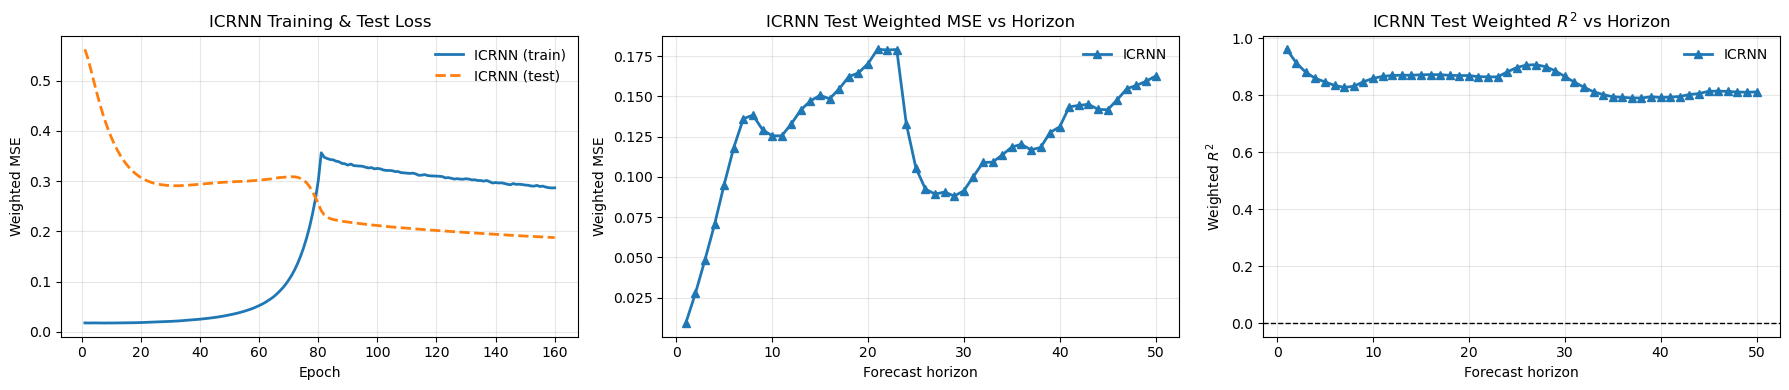


Per-trial post-stim weighted MSE (first 50 steps, test set, ICRNN):
  Trial 9: wMSE = 0.315390
  Trial 12: wMSE = 0.104324
  Trial 15: wMSE = 0.102065
  Trial 16: wMSE = 0.047940 <-- best
  Trial 18: wMSE = 1.027472
  Trial 19: wMSE = 0.529132
  Trial 24: wMSE = 0.252874
  Trial 29: wMSE = 0.559747
  Trial 30: wMSE = 0.638897
  Trial 31: wMSE = 0.257349
  Trial 51: wMSE = 1.693599
  Trial 55: wMSE = 0.066172
  Trial 56: wMSE = 0.170363
  Trial 60: wMSE = 0.114127
  Trial 66: wMSE = 0.505542
  Trial 75: wMSE = 0.542968
  Trial 78: wMSE = 0.111125
  Trial 84: wMSE = 0.146818
  Trial 94: wMSE = 0.223068
  Trial 97: wMSE = 0.615337
  Trial 98: wMSE = 0.341701
  Trial 100: wMSE = 0.189793
  Trial 101: wMSE = 0.231197
  Trial 104: wMSE = 0.413996
  Trial 105: wMSE = 0.396887
  Trial 109: wMSE = 0.221654
  Trial 131: wMSE = 0.260277
  Trial 133: wMSE = 0.259364
  Trial 138: wMSE = 0.533973
  Trial 143: wMSE = 1.309841
  Trial 144: wMSE = 1.578572
  Trial 153: wMSE = 0.527387
  Trial 158: wMS

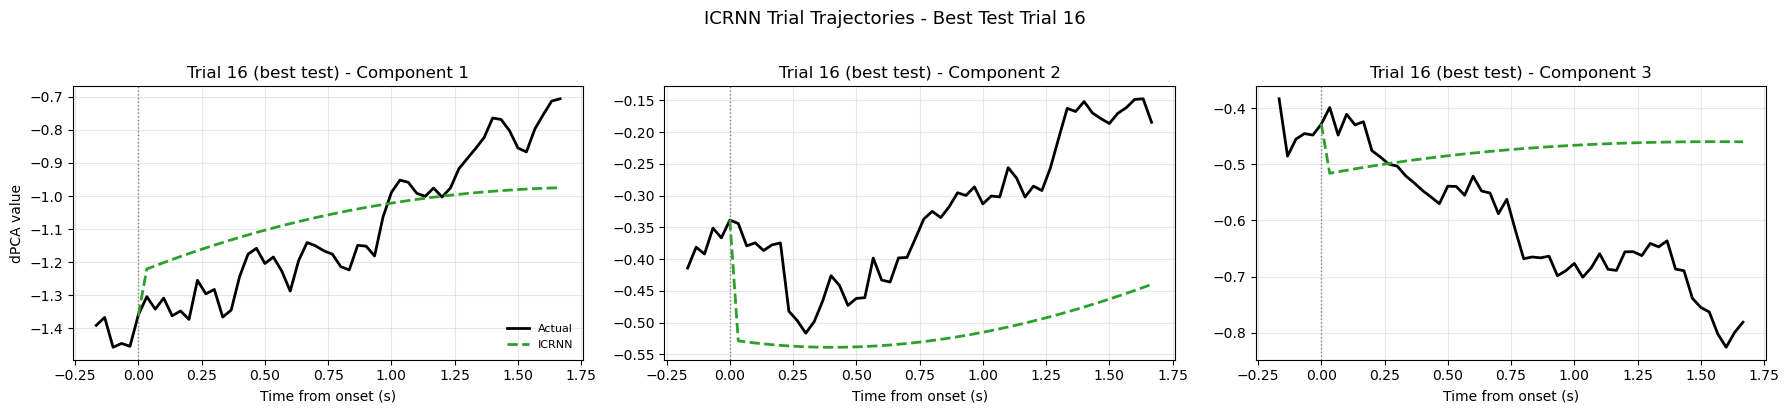

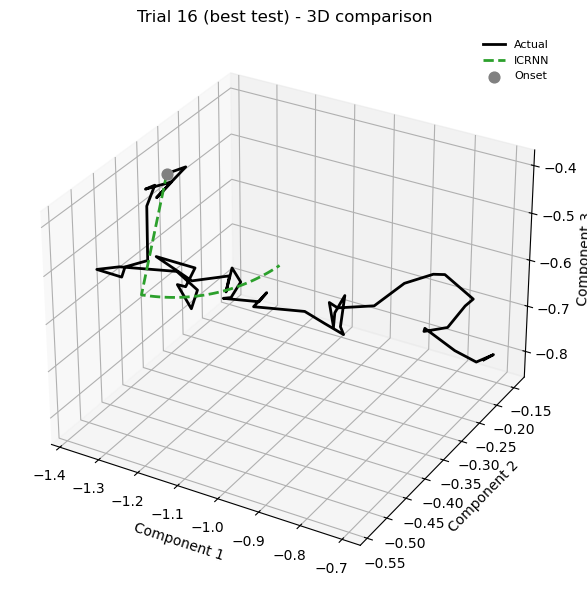

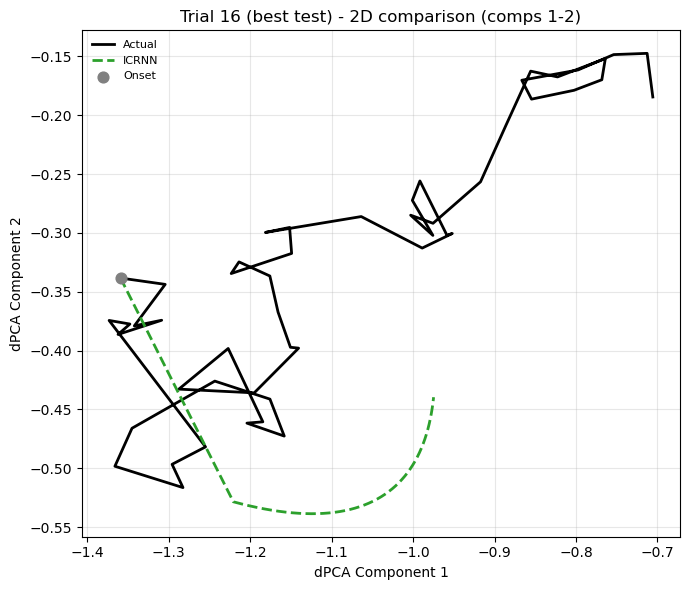

Training time (ICRNN): 469.94 s (2.9371 s/epoch)
Inference time (ICRNN): 0.023391 s

ICRNN weighted metrics (first 5 horizons):
   h    ICRNN MSE     ICRNN R²
t+01      0.00929      0.96162
t+02      0.02766      0.91376
t+03      0.04855      0.88041
t+04      0.07050      0.85934
t+05      0.09524      0.84697


In [7]:
import importlib
import icrnn_cell12

importlib.reload(icrnn_cell12)
from icrnn_cell12 import run_icrnn_cell12_and_export

# Runs the imported ICRNN pipeline and exports cell-12-style outputs to globals().
result_icrnn = run_icrnn_cell12_and_export(globals(), plot=True, verbose=True)

# Model Predictive Control (MPC) with Convex Neural Dynamics

In this section, we apply the offline-trained **ICRNN model** inversely as an optimizer to recover the ideal photostimulation vector ($\mathbf{v}$) required to achieve a specific target trajectory.

### 1. Goal
Instead of an arbitrary artificial closed-loop tracking setup, we will evaluate the system realistically. We take a true biological trial (e.g., Trial with ID 1) where specific neurons were systematically stimulated. We track its real latent trajectory following the stimulation onset. 

With only the pre-stimulation state and the target post-stimulation trajectory available, we ask the MPC optimization loop to guess **a single steady vector of stimulation** that would yield that trajectory. Then, we compare the MPC's optimized selection with the *true ground truth vector* physically stimulated in that trial.

### 2. Constraints and Parameters
*   **Prediction Window**: $H_p = 20$ timesteps (~0.66 seconds into the future).
*   **Single-Shot Output**: The algorithm restricts its output to a single static vector representing the targeting instructions right at the stimulation onset.
*   **Binary Control Constraint**: Targeted photostimulation neurons are either ON (`1`) or OFF (`0`). Thus, the inference occurs as a **Mixed-Integer Optimal Control** problem.

### 3. Optimization Strategy (Straight-Through Estimator)
Because neural networks (like our `ICRNNCell`) struggle with discrete step functions due to zeroed-out gradients, formulating optimization for strict binary mapping requires differentiable relaxations:

1.  **Logits**: We optimize a continuous unconstrained variable (`planned_v_logits`).
2.  **Sigmoid Activation**: We compress logits into a probability probability range via $v_{cont} = \sigma(v_{logits})$.
3.  **Hard Thresholding**: The *actual* stimulation applied to the dynamics is a hard boolean evaluation: $v_{bin} = (v_{cont} \ge 0.5)$.
4.  **Straight-Through Estimator (STE)**: To preserve backpropagation, we evaluate `v_effective = v_bin.detach() - v_cont.detach() + v_cont`. This allows PyTorch to push exclusively binary array (`0, 1`) values forward into the physics simulation, but seamlessly ignore the step-function during backward differentiation.

In [35]:
import torch
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We identify a trial with actual stimulation. 
# (If we pick a control trial with no stim, the optimization problem is trivial / meaningless).
stim_trials = np.where(v.sum(axis=(1,2)) > 0)[0]
tgt_trial_id = stim_trials[0] # Try trial 1 or change this to your preferred stimulated trial

# --- Single Vector Inferencing Settings ---
H_p = 20                 # Horizon over which we match the trajectory
n_cells = s0['n_cells']
opt_iters = 150          # More iterations for a single static shot
lr_mpc = 0.5
lambda_u = 0.05          # Light penalty to encourage sparsity (otherwise tries to fire everything)

t_start = zero_idx       # Stimulation onset in terms of array index

icrnn_cell = ema_icrnn.shadow.cell
icrnn_cell.eval()

# The exact trajectory this trial took post-onset
z_target_full = torch.from_numpy(z_trial_n[tgt_trial_id]).to(device)  # (T, d_z)
z_tgt_window = z_target_full[t_start + 1 : t_start + 1 + H_p].unsqueeze(0) # (1, H_p, d_z)

# The true stimulation binary vector that was applied in real life
true_v = torch.from_numpy(v[tgt_trial_id, t_start]).float().to(device).unsqueeze(0)  # (1, n_cells)

# Ensure H_p doesn't overflow
actual_Hp = z_tgt_window.shape[1]

# Initial condition: The data of that trial right BEFORE the next step is predicted
z_curr = z_target_full[t_start].clone().unsqueeze(0)  # (1, d_z)
z_curr_baseline = z_curr.clone()

# We optimize just ONE single static vector of logits for the entire prediction horizon
# -2.0 init makes it slightly off by default so we don't start with 50/50 everywhere
planned_v_logits = (-2.0 * torch.ones(1, n_cells, device=device)).requires_grad_(True)
optimizer_mpc = torch.optim.AdamW([planned_v_logits], lr=lr_mpc)

print(f"Tracking Trajectory for Trial {tgt_trial_id} over {actual_Hp} steps.")
print(f"True stimulation vector has {true_v.sum().item():.0f} / {n_cells} cells active.")

t0_opt = time.perf_counter()

# Optimization over just this single decision
loss_history = []
dist_history = []  # To track vector distance over iterations
for _ in range(opt_iters):
    optimizer_mpc.zero_grad()
    
    # Discretize via Straight-Through Estimator
    v_continuous = torch.sigmoid(planned_v_logits)
    v_binary = (v_continuous >= 0.5).float()
    v_k_effective = v_binary.detach() - v_continuous.detach() + v_continuous
    
    # Track distance (Hamming / L1 distance between binary predictions and true vector)
    current_dist = torch.sum(torch.abs(v_binary - true_v)).item()
    dist_history.append(current_dist)
    
    # Rollout predictions using the SAME stimulation vector at every timestep 
    # (matching reality where v is constant over the trial)
    z_pred = []
    z_roll = z_curr
    for k in range(actual_Hp):
        z_roll = icrnn_cell(z_roll, v_k_effective)
        z_pred.append(z_roll)
    
    z_pred = torch.stack(z_pred, dim=1) # (1, actual_Hp, d_z)
    
    # 1) State Tracking MSE against what ACTUALLY happened in the trial
    loss_tracking = F.mse_loss(z_pred, z_tgt_window)
    
    # 2) Control Effort Penalty (L1 penalty on probabilities)
    loss_control = lambda_u * torch.sum(v_continuous) / n_cells
    
    loss_mpc = loss_tracking + loss_control
    loss_mpc.backward()
    optimizer_mpc.step()
    
    loss_history.append(loss_mpc.item())

t1_opt = time.perf_counter()

# Final optimized hard binary vector
opt_v_binary = (torch.sigmoid(planned_v_logits) >= 0.5).float().detach()

print(f"Optimization finished in {t1_opt - t0_opt:.3f} seconds.")
print(f"Optimized stimulation vector has {opt_v_binary.sum().item():.0f} cells active.")

# Simulate baseline (0 stimulation) vs true stimulation vs optimized stimulation
with torch.no_grad():
    z_roll_opt = z_curr.clone()
    z_roll_true = z_curr.clone()
    z_roll_base = z_curr.clone()
    
    z_pred_opt = []
    z_pred_true = []
    z_pred_base = []
    
    for k in range(actual_Hp):
        z_roll_opt = icrnn_cell(z_roll_opt, opt_v_binary)
        z_roll_true = icrnn_cell(z_roll_true, true_v)
        z_roll_base = icrnn_cell(z_roll_base, torch.zeros_like(true_v))
        
        z_pred_opt.append(z_roll_opt)
        z_pred_true.append(z_roll_true)
        z_pred_base.append(z_roll_base)
        
z_pred_opt = torch.stack(z_pred_opt, dim=1).squeeze().cpu().numpy()
z_pred_true = torch.stack(z_pred_true, dim=1).squeeze().cpu().numpy()
z_pred_base = torch.stack(z_pred_base, dim=1).squeeze().cpu().numpy()
z_tgt_arr = z_tgt_window.squeeze().cpu().numpy()

Tracking Trajectory for Trial 1 over 20 steps.
True stimulation vector has 23 / 471 cells active.
Optimization finished in 1.816 seconds.
Optimized stimulation vector has 18 cells active.


--- INFERENCE RESULTS ---
Overall Cell Targeting Accuracy: 91.30%
Confusion Matrix (True \ Predicted):
TN: 430 | FP: 18
FN: 23 | TP: 0

--- PROPORTIONS (Out of Total Neurons) ---
True Negatives (Correctly ignored):   91.3%
True Positives (Correctly stimulated): 0.0%
False Positives (Mistakenly stim'd):   3.8%
False Negatives (Missed targets):      4.9%
Ratio of True (TN+TP) to False (FP+FN): 10.49


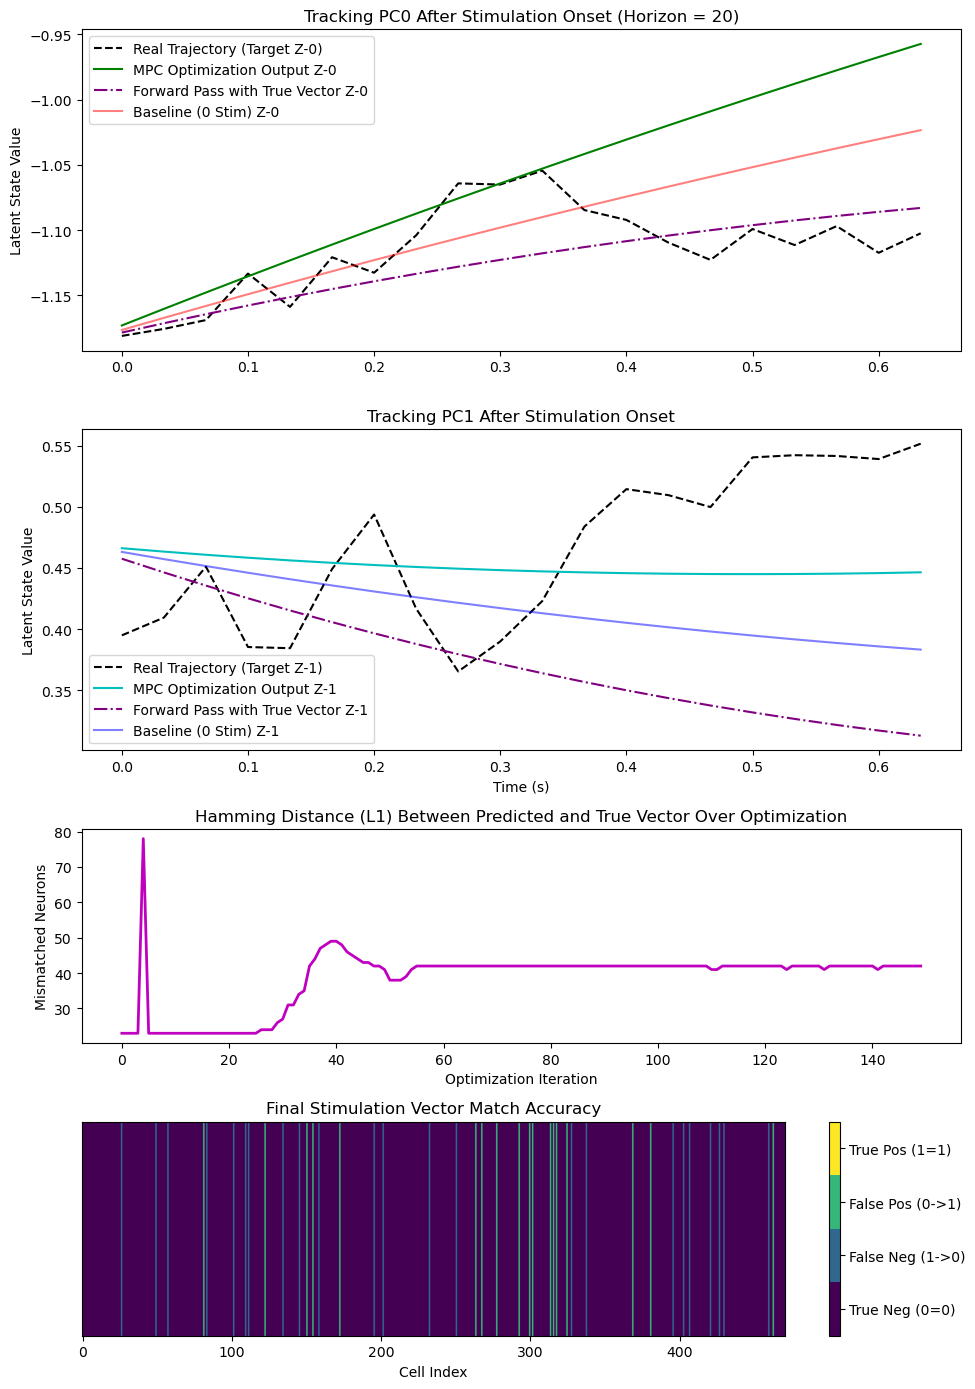

In [36]:
# --- Evaluate and Plot Single Output ---
from sklearn.metrics import accuracy_score, confusion_matrix

true_v_arr = true_v.squeeze().cpu().numpy()
opt_v_arr = opt_v_binary.squeeze().cpu().numpy()

acc = accuracy_score(true_v_arr, opt_v_arr)
cm = confusion_matrix(true_v_arr, opt_v_arr, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()
total_cells = len(true_v_arr)

print("--- INFERENCE RESULTS ---")
print(f"Overall Cell Targeting Accuracy: {acc*100:.2f}%")
print(f"Confusion Matrix (True \\ Predicted):\nTN: {tn} | FP: {fp}\nFN: {fn} | TP: {tp}")
print("\n--- PROPORTIONS (Out of Total Neurons) ---")
print(f"True Negatives (Correctly ignored):   {tn/total_cells*100:.1f}%")
print(f"True Positives (Correctly stimulated): {tp/total_cells*100:.1f}%")
print(f"False Positives (Mistakenly stim'd):   {fp/total_cells*100:.1f}%")
print(f"False Negatives (Missed targets):      {fn/total_cells*100:.1f}%")
if (fp+fn) > 0:
    print(f"Ratio of True (TN+TP) to False (FP+FN): {(tn+tp)/(fp+fn):.2f}")

fig, axs = plt.subplots(4, 1, figsize=(10, 14), gridspec_kw={'height_ratios': [1.5, 1.5, 1, 1]})

time_axis = np.arange(actual_Hp) / 30.0  # seconds

# 1. State Tracking for PC0
axs[0].plot(time_axis, z_tgt_arr[:, 0], 'k--', label='Real Trajectory (Target Z-0)')
axs[0].plot(time_axis, z_pred_opt[:, 0], 'g', label='MPC Optimization Output Z-0')
axs[0].plot(time_axis, z_pred_true[:, 0], 'purple', linestyle='-.', label='Forward Pass with True Vector Z-0')
axs[0].plot(time_axis, z_pred_base[:, 0], 'r', label='Baseline (0 Stim) Z-0', alpha=0.5)
axs[0].set_title(f'Tracking PC0 After Stimulation Onset (Horizon = {actual_Hp})')
axs[0].set_ylabel('Latent State Value')
axs[0].legend(loc='best')

# 2. State Tracking for PC1
axs[1].plot(time_axis, z_tgt_arr[:, 1], 'k--', label='Real Trajectory (Target Z-1)')
axs[1].plot(time_axis, z_pred_opt[:, 1], 'c', label='MPC Optimization Output Z-1')
axs[1].plot(time_axis, z_pred_true[:, 1], 'purple', linestyle='-.', label='Forward Pass with True Vector Z-1')
axs[1].plot(time_axis, z_pred_base[:, 1], 'b', label='Baseline (0 Stim) Z-1', alpha=0.5)
axs[1].set_title(f'Tracking PC1 After Stimulation Onset')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Latent State Value')
axs[1].legend(loc='best')

# 3. Vector Distance Trajectory During Optimization
iters_axis = np.arange(len(dist_history))
axs[2].plot(iters_axis, dist_history, 'm-', linewidth=2)
axs[2].set_title('Hamming Distance (L1) Between Predicted and True Vector Over Optimization')
axs[2].set_xlabel('Optimization Iteration')
axs[2].set_ylabel('Mismatched Neurons')

# 4. Vector Match Heatmap
# We'll plot a bar matrix to show False Positive / False Negative / True Positives
match_colors = np.zeros(n_cells)
match_colors[(true_v_arr == 1) & (opt_v_arr == 1)] = 3  # TP (Green)
match_colors[(true_v_arr == 0) & (opt_v_arr == 1)] = 2  # FP (Red)
match_colors[(true_v_arr == 1) & (opt_v_arr == 0)] = 1  # FN (Yellow)
# TN remains 0 (White/Empty)

cmap = plt.get_cmap('viridis', 4)
img = axs[3].imshow(match_colors.reshape(1, -1), aspect='auto', cmap=cmap, vmin=-0.5, vmax=3.5)
axs[3].set_title('Final Stimulation Vector Match Accuracy')
axs[3].set_xlabel('Cell Index')
axs[3].set_yticklabels([])
axs[3].set_yticks([])

# Add a colorbar with discrete labels
cbar = fig.colorbar(img, ax=axs[3], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['True Neg (0=0)', 'False Neg (1->0)', 'False Pos (0->1)', 'True Pos (1=1)'])

plt.tight_layout()
plt.show()